# TARDIS — Weather Model Training Notebook

All logic stays in this notebook because `scripts/model/` is specialised for train delay prediction. This notebook follows the same orchestration style as `tardis_model.ipynb`, but targets the cleaned Meteo-France dataset.

| Section | Role |
|--------|------|
| Imports | Load libraries and project settings |
| Data loading | Read `data/processed/meteo/cleaned_meteo_dataset.csv` |
| Target | Predict daily mean temperature `TM` by default |
| Preprocessing | Impute numeric values, scale them, encode categorical values |
| Models | Train Linear Regression, Ridge, Random Forest, Gradient Boosting, XGBoost and LightGBM when available |
| Evaluation | Compare RMSE, MAE and R2 against a mean baseline |
| Export | Save the best pipeline to `meteo_model.joblib` |

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

if "." not in sys.path:
    sys.path.insert(0, ".")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_STATE = 42
print(f"✓ Repertoire : {os.getcwd()}")

✓ Repertoire : /home/erwan/EpitechProjects/Tardis


## 2. Chargement & exploration des donnees

In [2]:
DATASET_PATH = Path("data/processed/meteo/cleaned_meteo_dataset.csv")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset introuvable : {DATASET_PATH}. Lance d'abord tardis_meteo_eda.ipynb ou la pipeline meteo."
    )

TARGET = "TM"  # Temperature moyenne journaliere. Change possible: "TX", "TN", "RR", "FFM".
MAX_ROWS = 250_000  # Ajuste a None pour utiliser tout le dataset.

base_cols = [
    "NUM_POSTE", "NOM_USUEL", "LAT", "LON", "ALTI", "date", "year", "month", "season",
    "RR", "FFM", "wind_category", "precip_category",
    "NEIG", "BROU", "ORAG", "GRELE", "VERGLAS", "SOLNEIGE", "GELEE", TARGET,
]

available_cols = pd.read_csv(DATASET_PATH, nrows=0).columns.tolist()
usecols = [col for col in base_cols if col in available_cols]
df = pd.read_csv(DATASET_PATH, usecols=usecols, parse_dates=["date"], low_memory=False)

if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=RANDOM_STATE).sort_values("date")

df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_year"] = df["date"].dt.dayofyear

print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Periode : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Stations: {df['NUM_POSTE'].nunique():,}")
print(f"Cible   : {TARGET}")
print(f"  -> Moyenne : {df[TARGET].mean():.2f} | Ecart-type : {df[TARGET].std():.2f} | Max : {df[TARGET].max():.1f}")
print(f"  -> Valeurs manquantes sur la cible : {df[TARGET].isna().sum():,}")

Dataset : 250,000 lignes x 23 colonnes
Periode : 1950-01-01 -> 2026-05-16
Stations: 200
Cible   : TM
  -> Moyenne : 10.76 | Ecart-type : 6.93 | Max : 31.0
  -> Valeurs manquantes sur la cible : 219,432


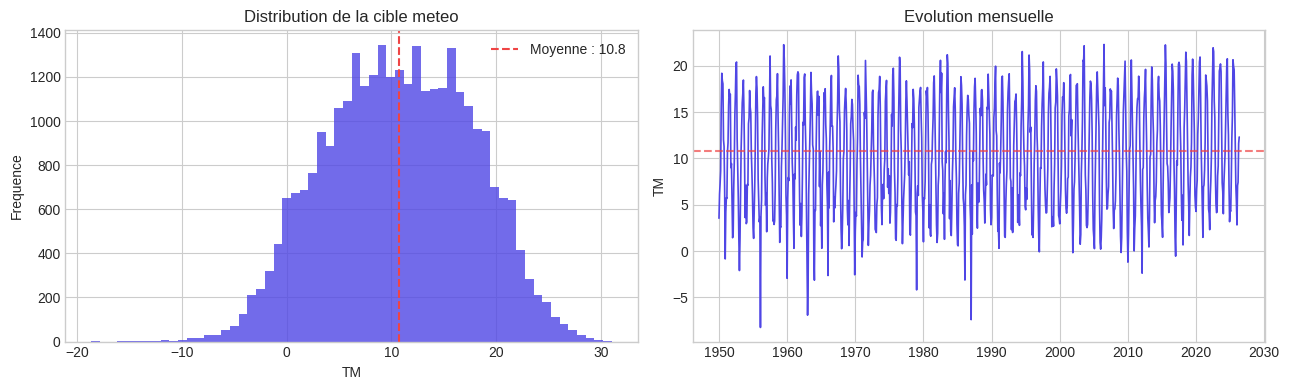

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET].dropna(), bins=60, color="#4f46e5", alpha=0.8, edgecolor="none")
axes[0].axvline(df[TARGET].mean(), color="#ef4444", linestyle="--", label=f"Moyenne : {df[TARGET].mean():.1f}")
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel("Frequence")
axes[0].set_title("Distribution de la cible meteo")
axes[0].legend()

monthly = df.groupby(["year", "month"])[TARGET].mean().reset_index()
monthly["period"] = pd.to_datetime(monthly[["year", "month"]].assign(day=1))
axes[1].plot(monthly["period"], monthly[TARGET], color="#4f46e5", linewidth=1.2)
axes[1].axhline(df[TARGET].mean(), color="#ef4444", linestyle="--", alpha=0.7)
axes[1].set_xlabel("")
axes[1].set_ylabel(TARGET)
axes[1].set_title("Evolution mensuelle")

plt.tight_layout()
plt.show()

## 3. Preparation des donnees & split

**Strategie anti-fuite de donnees :** pour predire `TM`, on n'utilise pas `TN`, `TX`, `TAMPLI` ou `temp_amplitude`, car ces colonnes encodent directement la temperature du meme jour. Le modele apprend surtout le signal station + calendrier + contexte meteo.

In [4]:
numeric_features = [
    "LAT", "LON", "ALTI", "year", "month", "day_of_week", "day_of_year", "RR", "FFM",
    "NEIG", "BROU", "ORAG", "GRELE", "VERGLAS", "SOLNEIGE", "GELEE",
]
categorical_features = ["NUM_POSTE", "NOM_USUEL", "season", "wind_category", "precip_category"]

numeric_features = [col for col in numeric_features if col in df.columns and col != TARGET]
categorical_features = [col for col in categorical_features if col in df.columns and col != TARGET]
all_features = numeric_features + categorical_features

df_model = df.dropna(subset=[TARGET]).copy()
X = df_model[all_features]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot),
        ]), categorical_features),
    ],
    remainder="drop",
)

print(f"Echantillon d'entrainement : {len(X_train):,} lignes")
print(f"Echantillon de test        : {len(X_test):,} lignes")
print(f"Features numeriques        : {numeric_features}")
print(f"Features categor.          : {categorical_features}")

Echantillon d'entrainement : 24,454 lignes
Echantillon de test        : 6,114 lignes
Features numeriques        : ['LAT', 'LON', 'ALTI', 'year', 'month', 'day_of_week', 'day_of_year', 'RR', 'FFM', 'NEIG', 'BROU', 'ORAG', 'GRELE', 'VERGLAS', 'SOLNEIGE', 'GELEE']
Features categor.          : ['NUM_POSTE', 'NOM_USUEL', 'season', 'wind_category', 'precip_category']


In [5]:
def compute_metrics(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

baseline_pred = np.full_like(y_test.to_numpy(dtype=float), y_train.mean(), dtype=float)
baseline = compute_metrics(y_test, baseline_pred)

print("Baseline (predire la moyenne d'entrainement) :")
print(f"  RMSE : {baseline['RMSE']:.3f}")
print(f"  MAE  : {baseline['MAE']:.3f}")
print(f"  R2   : {baseline['R2']:.4f}")

Baseline (predire la moyenne d'entrainement) :
  RMSE : 7.000
  MAE  : 5.773
  R2   : -0.0004


## 4. Entrainement complet

Comme dans le notebook train, cette section entraine 6 modeles de base puis optimise le meilleur avec `GridSearchCV`, ce qui donne 7 resultats au total quand XGBoost et LightGBM sont disponibles.


In [6]:
candidates = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=160, max_depth=24, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=180, learning_rate=0.06, max_depth=4,
        random_state=RANDOM_STATE
    ),
}

try:
    import xgboost as xgb
    candidates["XGBoost"] = xgb.XGBRegressor(
        n_estimators=260, learning_rate=0.06, max_depth=6,
        subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, tree_method="hist", verbosity=0,
    )
except ImportError:
    print("XGBoost indisponible")

try:
    import lightgbm as lgb
    candidates["LightGBM"] = lgb.LGBMRegressor(
        n_estimators=320, learning_rate=0.05, max_depth=8,
        num_leaves=63, subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, verbosity=-1,
    )
except ImportError:
    print("LightGBM indisponible")

all_results = {}
all_pipelines = {}

for name, model in candidates.items():
    pipe = Pipeline([("prep", clone(preprocessor)), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    all_results[name] = compute_metrics(y_test, preds)
    all_pipelines[name] = pipe
    print(
        f"{name:20s} | RMSE: {all_results[name]['RMSE']:.3f} "
        f"| MAE: {all_results[name]['MAE']:.3f} | R2: {all_results[name]['R2']:.4f}"
    )

best_base_name = min(all_results, key=lambda key: all_results[key]["RMSE"])
print(f"\nOptimisation : {best_base_name}")

if best_base_name == "LightGBM" and "lgb" in globals():
    tuned_model = lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1)
    tuned_grid = {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [6, 8],
        "model__num_leaves": [31, 63],
    }
elif best_base_name == "XGBoost" and "xgb" in globals():
    tuned_model = xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, tree_method="hist")
    tuned_grid = {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [4, 6],
        "model__subsample": [0.8, 1.0],
    }
elif best_base_name == "Random Forest":
    tuned_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    tuned_grid = {
        "model__n_estimators": [160, 260],
        "model__max_depth": [18, 24, None],
        "model__min_samples_leaf": [1, 2],
    }
else:
    tuned_model = GradientBoostingRegressor(random_state=RANDOM_STATE)
    tuned_grid = {
        "model__n_estimators": [160, 240],
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__max_depth": [3, 4],
    }

tuned_search = GridSearchCV(
    Pipeline([("prep", clone(preprocessor)), ("model", tuned_model)]),
    tuned_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1,
)
tuned_search.fit(X_train, y_train)

best_name = f"{best_base_name} (tuned)"
best_pipeline = tuned_search.best_estimator_
tuned_preds = best_pipeline.predict(X_test)
all_results[best_name] = compute_metrics(y_test, tuned_preds)
all_pipelines[best_name] = best_pipeline

print(f"\nBest params : {tuned_search.best_params_}")
print(f"CV RMSE     : {-tuned_search.best_score_:.3f}")
print(
    f"{best_name:20s} | RMSE: {all_results[best_name]['RMSE']:.3f} "
    f"| MAE: {all_results[best_name]['MAE']:.3f} | R2: {all_results[best_name]['R2']:.4f}"
)
print(f"\nMeilleur modele final : {best_name}")


Linear Regression    | RMSE: 4.262 | MAE: 3.393 | R2: 0.6292


Ridge                | RMSE: 4.262 | MAE: 3.393 | R2: 0.6292


Random Forest        | RMSE: 2.851 | MAE: 2.238 | R2: 0.8341


Gradient Boosting    | RMSE: 3.228 | MAE: 2.578 | R2: 0.7873


XGBoost              | RMSE: 3.004 | MAE: 2.392 | R2: 0.8158


LightGBM             | RMSE: 2.912 | MAE: 2.311 | R2: 0.8269

Optimisation : Random Forest
Fitting 3 folds for each of 12 candidates, totalling 36 fits



Best params : {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 260}
CV RMSE     : 2.962
Random Forest (tuned) | RMSE: 2.846 | MAE: 2.234 | R2: 0.8346

Meilleur modele final : Random Forest (tuned)


## 5. Tableau des resultats

In [7]:
results_df = pd.DataFrame(all_results).T.sort_values("RMSE")
results_df.loc["Baseline"] = baseline

display(
    results_df
    .style
    .format({"RMSE": "{:.3f}", "MAE": "{:.3f}", "R2": "{:.4f}"})
    .background_gradient(cmap="RdYlGn_r", subset=["RMSE", "MAE"])
    .background_gradient(cmap="RdYlGn", subset=["R2"])
)

,RMSE,MAE,R2
Random Forest (tuned),2.846,2.234,0.8346
Random Forest,2.851,2.238,0.8341
LightGBM,2.912,2.311,0.8269
XGBoost,3.004,2.392,0.8158
Gradient Boosting,3.228,2.578,0.7873
Ridge,4.262,3.393,0.6292
Linear Regression,4.262,3.393,0.6292
Baseline,7.000,5.773,-0.0004


## 6. Comparaison visuelle

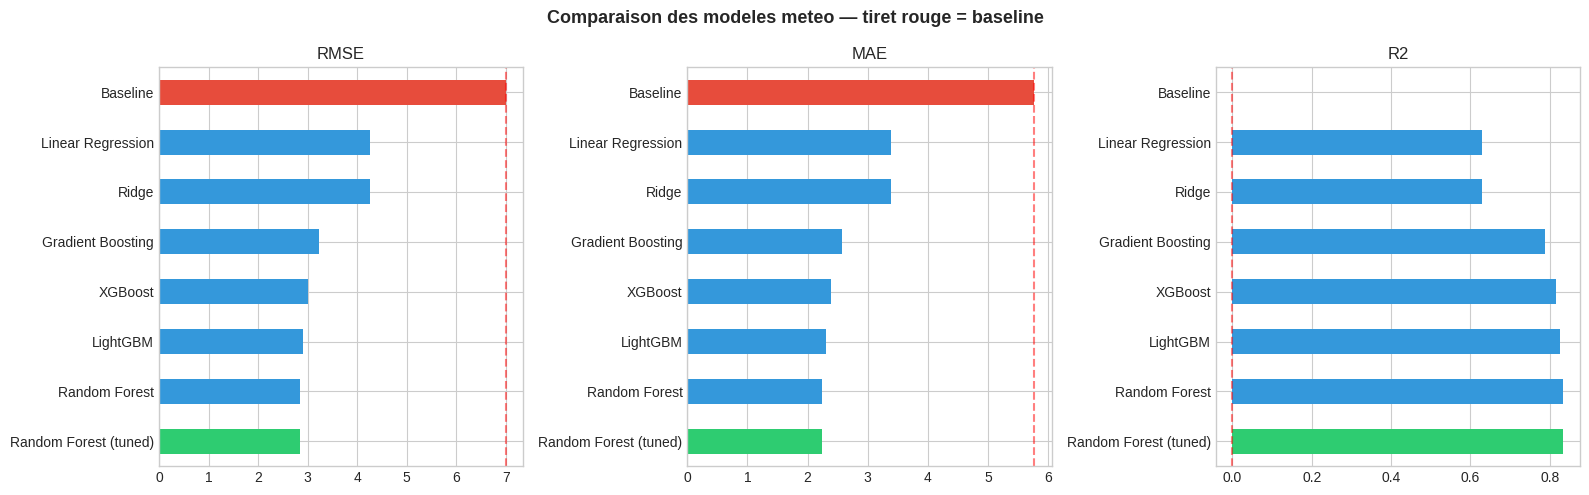

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, asc in zip(axes, ["RMSE", "MAE", "R2"], [True, True, False]):
    vals = results_df[metric].sort_values(ascending=asc)
    colors = [
        "#e74c3c" if idx == "Baseline"
        else "#2ecc71" if idx == vals.index[0]
        else "#3498db"
        for idx in vals.index
    ]
    vals.plot(kind="barh", ax=ax, color=colors)
    ax.set_title(metric)
    ax.axvline(results_df.loc["Baseline", metric], color="red", linestyle="--", alpha=0.5)

plt.suptitle("Comparaison des modeles meteo — tiret rouge = baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Predit vs reel + residus

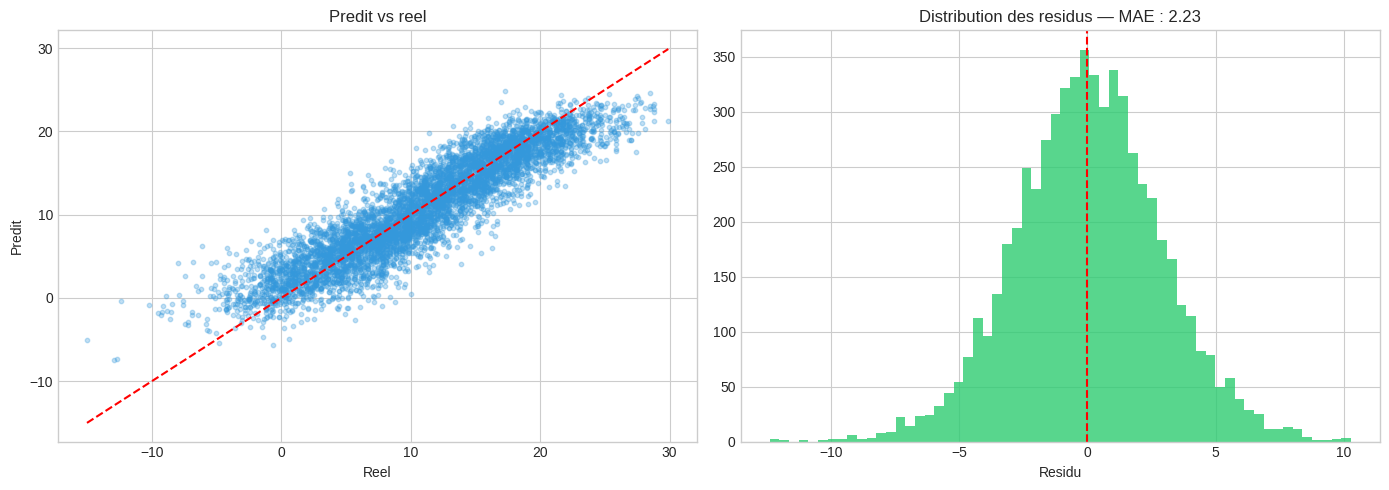

In [9]:
prod_preds = best_pipeline.predict(X_test)
residuals = y_test.to_numpy() - prod_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, prod_preds, alpha=0.3, s=10, color="#3498db")
lims = [min(y_test.min(), prod_preds.min()), max(y_test.max(), prod_preds.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5)
axes[0].set_xlabel("Reel")
axes[0].set_ylabel("Predit")
axes[0].set_title("Predit vs reel")

axes[1].hist(residuals, bins=60, color="#2ecc71", alpha=0.8, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residu")
axes[1].set_title(f"Distribution des residus — MAE : {mean_absolute_error(y_test, prod_preds):.2f}")

plt.tight_layout()
plt.show()

## 8. Importance des variables

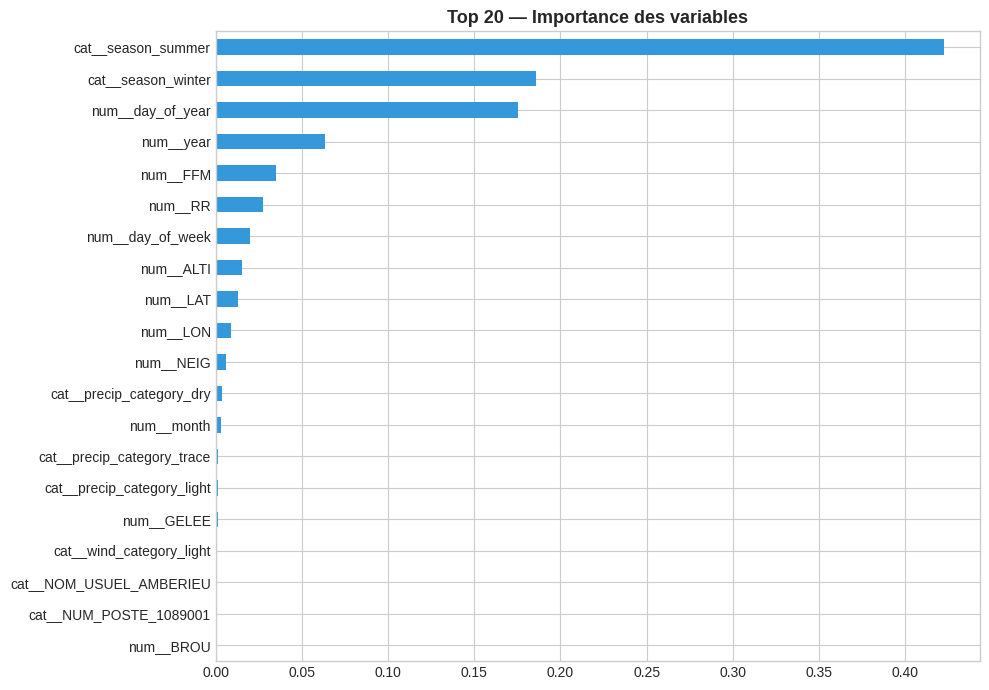

Top 10 :
  cat__season_summer                                      0.42225
  cat__season_winter                                      0.18566
  num__day_of_year                                        0.17539
  num__year                                               0.06349
  num__FFM                                                0.03476
  num__RR                                                 0.02735
  num__day_of_week                                        0.01991
  num__ALTI                                               0.01541
  num__LAT                                                0.01316
  num__LON                                                0.00888


In [10]:
prep_step = best_pipeline.named_steps["prep"]
feature_names = prep_step.get_feature_names_out().tolist()
final_estimator = best_pipeline.named_steps["model"]

if hasattr(final_estimator, "feature_importances_"):
    raw_importance = final_estimator.feature_importances_
elif hasattr(final_estimator, "coef_"):
    raw_importance = np.ravel(final_estimator.coef_)
else:
    raw_importance = np.zeros(len(feature_names))

importances = pd.Series(raw_importance, index=feature_names).abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Top 20 — Importance des variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 10 :")
for feat, val in importances.head(10).items():
    print(f"  {feat:55s} {val:.5f}")

## 9. Verification — predire quelques stations

In [11]:
examples = X_test.sample(5, random_state=RANDOM_STATE).copy()
example_preds = best_pipeline.predict(examples)

for idx, pred in zip(examples.index, example_preds):
    station = df_model.loc[idx, "NOM_USUEL"] if "NOM_USUEL" in df_model.columns else df_model.loc[idx, "NUM_POSTE"]
    date = df_model.loc[idx, "date"].date()
    real = df_model.loc[idx, TARGET]
    print(f"{str(station):30s} [{date}]  reel={real:6.2f}  predit={pred:6.2f}")

AMBERIEU                       [1970-06-22]  reel= 21.50  predit= 18.90
BRAINE                         [1999-06-30]  reel= 17.00  predit= 16.11
BLESMES                        [1990-07-13]  reel= 21.40  predit= 19.27
BELLEGARDE                     [2005-12-21]  reel= -0.80  predit= -1.42
MARTIGNY-COURPI                [2022-09-26]  reel= 10.80  predit= 13.28


## 10. Modele sauvegarde

In [12]:
MODELS_DIR = Path("models/meteo")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

artifact = {
    "pipeline": best_pipeline,
    "model_name": best_name,
    "target": TARGET,
    "features": all_features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "metrics": all_results[best_name],
}

metadata = {}
for name, pipe in all_pipelines.items():
    slug = (
        name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "_")
    )
    model_path = MODELS_DIR / f"{slug}.joblib"
    joblib.dump({"pipeline": pipe, "model_name": name, "target": TARGET}, model_path)
    metadata[name] = {
        "file": str(model_path),
        **{k: float(v) for k, v in all_results[name].items()},
    }

joblib.dump(artifact, "meteo_model.joblib")

metadata_out = {
    "target": TARGET,
    "best_model": best_name,
    "max_rows": MAX_ROWS,
    "results": metadata,
    "baseline": {k: float(v) for k, v in baseline.items()},
}

with open(MODELS_DIR / "metadata.json", "w") as f:
    json.dump(metadata_out, f, indent=2)

print(f"✓ {len(all_pipelines)} modeles sauvegardes dans {MODELS_DIR}/")
print(f"✓ Meilleur modele : {best_name}")
print("✓ Sauvegarde best : meteo_model.joblib")
print(f"✓ Metadata        : {MODELS_DIR / 'metadata.json'}")


✓ 7 modeles sauvegardes dans models/meteo/
✓ Meilleur modele : Random Forest (tuned)
✓ Sauvegarde best : meteo_model.joblib
✓ Metadata        : models/meteo/metadata.json
